# Base 2 — Gráficos exploratórios e STL

A exploração usa a grade horária preparada. Para não interpolar o alvo, a STL é calculada no maior trecho contínuo observado dentro do treino.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sns.set_theme(style='whitegrid')

def seasonal_strength(result):
    denom = np.nanvar(result.seasonal + result.resid)
    return np.nan if denom == 0 else max(0.0, 1 - np.nanvar(result.resid) / denom)

def trend_strength(result):
    denom = np.nanvar(result.trend + result.resid)
    return np.nan if denom == 0 else max(0.0, 1 - np.nanvar(result.resid) / denom)

BASE_DIR = ROOT / 'trabalho/bases/grupo2'
df = pd.read_csv(BASE_DIR / 'base2_limpa_preparada.csv', parse_dates=['date_time'])
train = pd.read_csv(BASE_DIR / 'base2_treino_preparada.csv', parse_dates=['date_time'])
df['hora'] = df['date_time'].dt.hour
df['dia_semana'] = df['date_time'].dt.day_name()
df['mes'] = df['date_time'].dt.month
display(df['traffic_volume'].describe().to_frame('traffic_volume'))
print('Lacunas horárias no artefato preparado:', int(df['traffic_volume'].isna().sum()))

,traffic_volume
count,40575.000000
mean,3290.650474
std,1984.772909
min,0.000000
25%,1248.500000
50%,3427.000000
75%,4952.000000
max,7280.000000


Lacunas horárias no artefato preparado: 11976


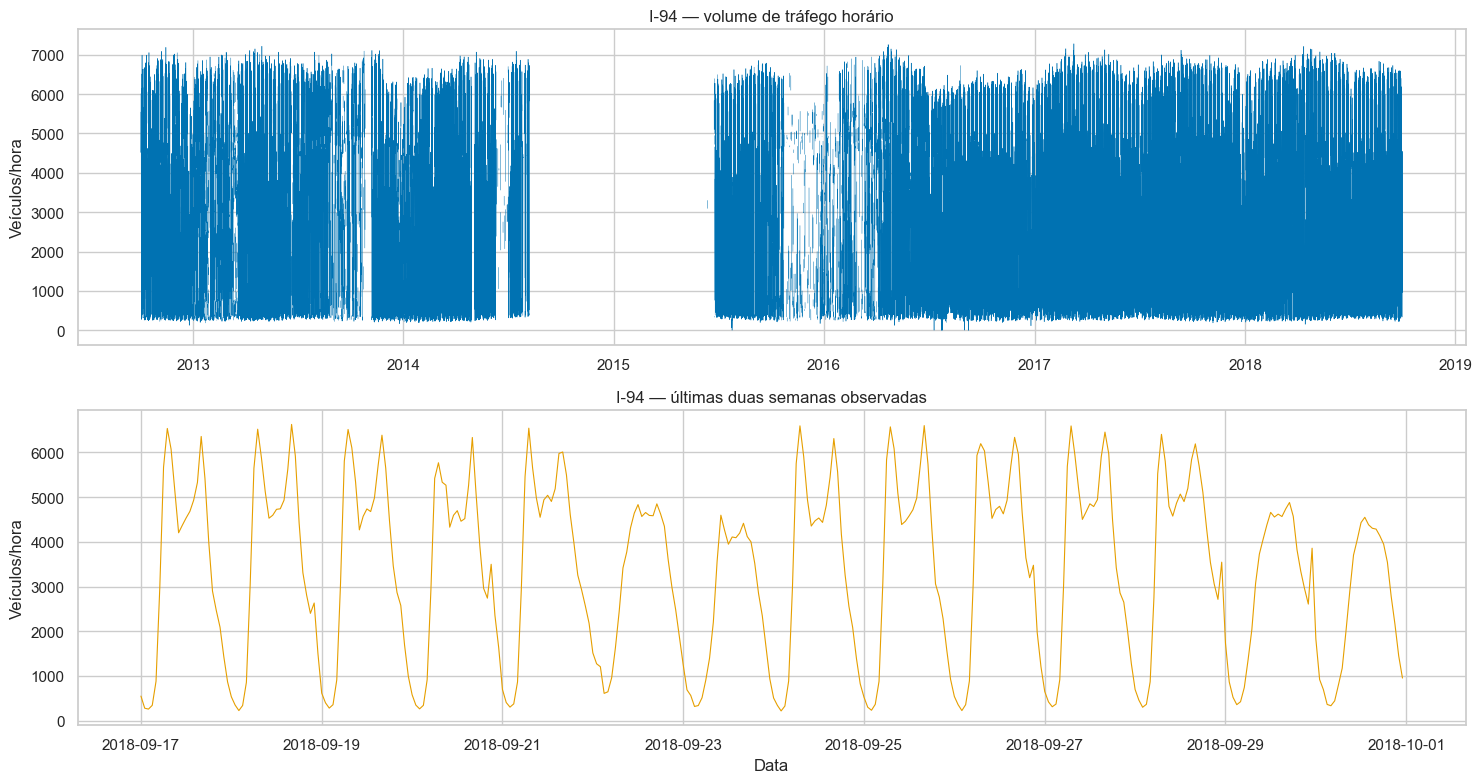

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=False)
axes[0].plot(df['date_time'], df['traffic_volume'], lw=.35, color='#0072b2')
axes[0].set(title='I-94 — volume de tráfego horário', ylabel='Veículos/hora')
recent = df.dropna(subset=['traffic_volume']).tail(24 * 14)
axes[1].plot(recent['date_time'], recent['traffic_volume'], lw=.8, color='#e69f00')
axes[1].set(title='I-94 — últimas duas semanas observadas', ylabel='Veículos/hora', xlabel='Data')
plt.tight_layout(); plt.show()

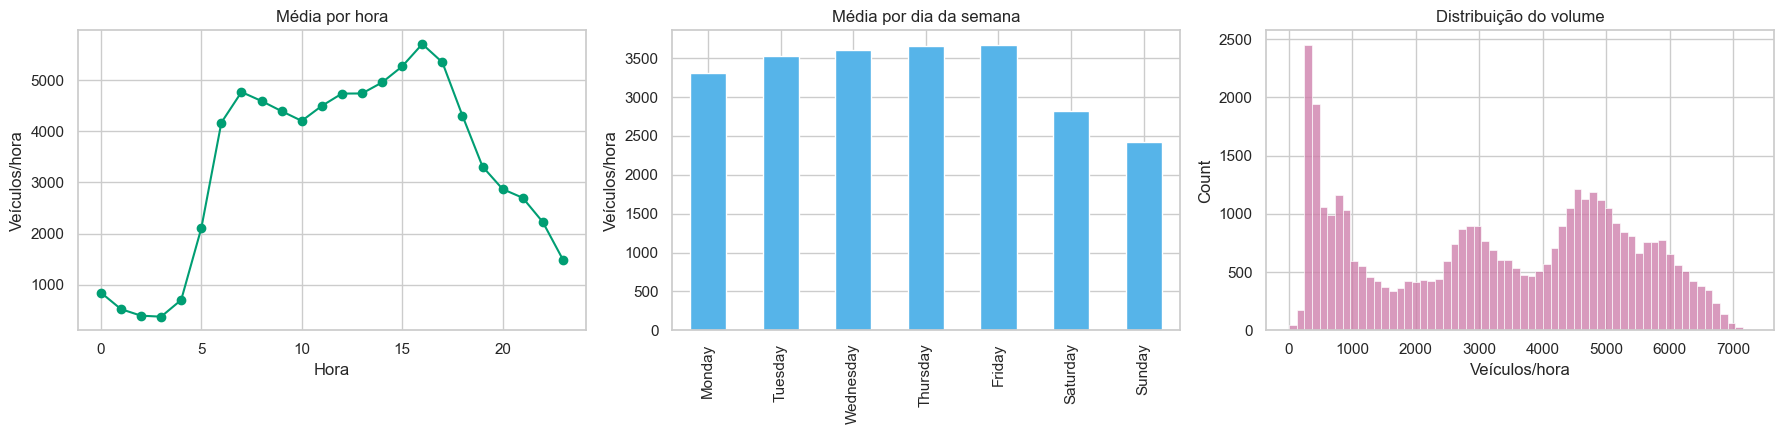

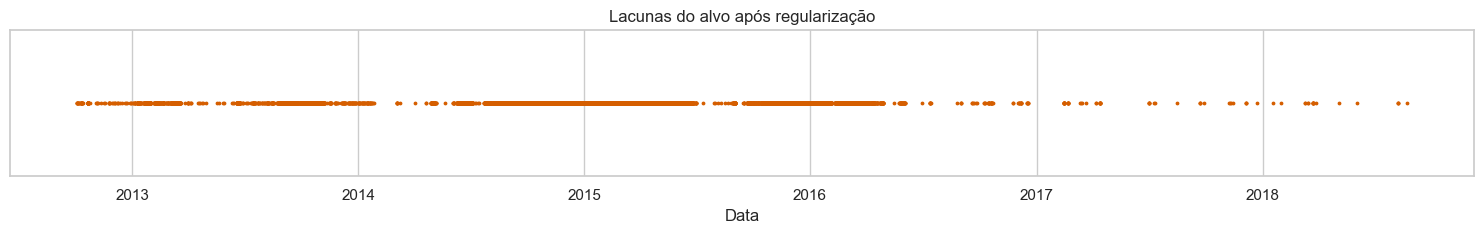

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
df.groupby('hora')['traffic_volume'].mean().plot(ax=axes[0], marker='o', color='#009e73')
axes[0].set(title='Média por hora', xlabel='Hora', ylabel='Veículos/hora')
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df.groupby('dia_semana')['traffic_volume'].mean().reindex(order).plot.bar(ax=axes[1], color='#56b4e9')
axes[1].set(title='Média por dia da semana', xlabel='', ylabel='Veículos/hora')
sns.histplot(df['traffic_volume'].dropna(), bins=60, ax=axes[2], color='#cc79a7')
axes[2].set(title='Distribuição do volume', xlabel='Veículos/hora')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(15, 2.5))
missing = df['traffic_volume'].isna()
ax.scatter(df.loc[missing, 'date_time'], np.ones(missing.sum()), s=3, color='#d55e00')
ax.set(title='Lacunas do alvo após regularização', xlabel='Data', yticks=[])
plt.tight_layout(); plt.show()

Maior trecho horário contínuo no treino: 1915 observações


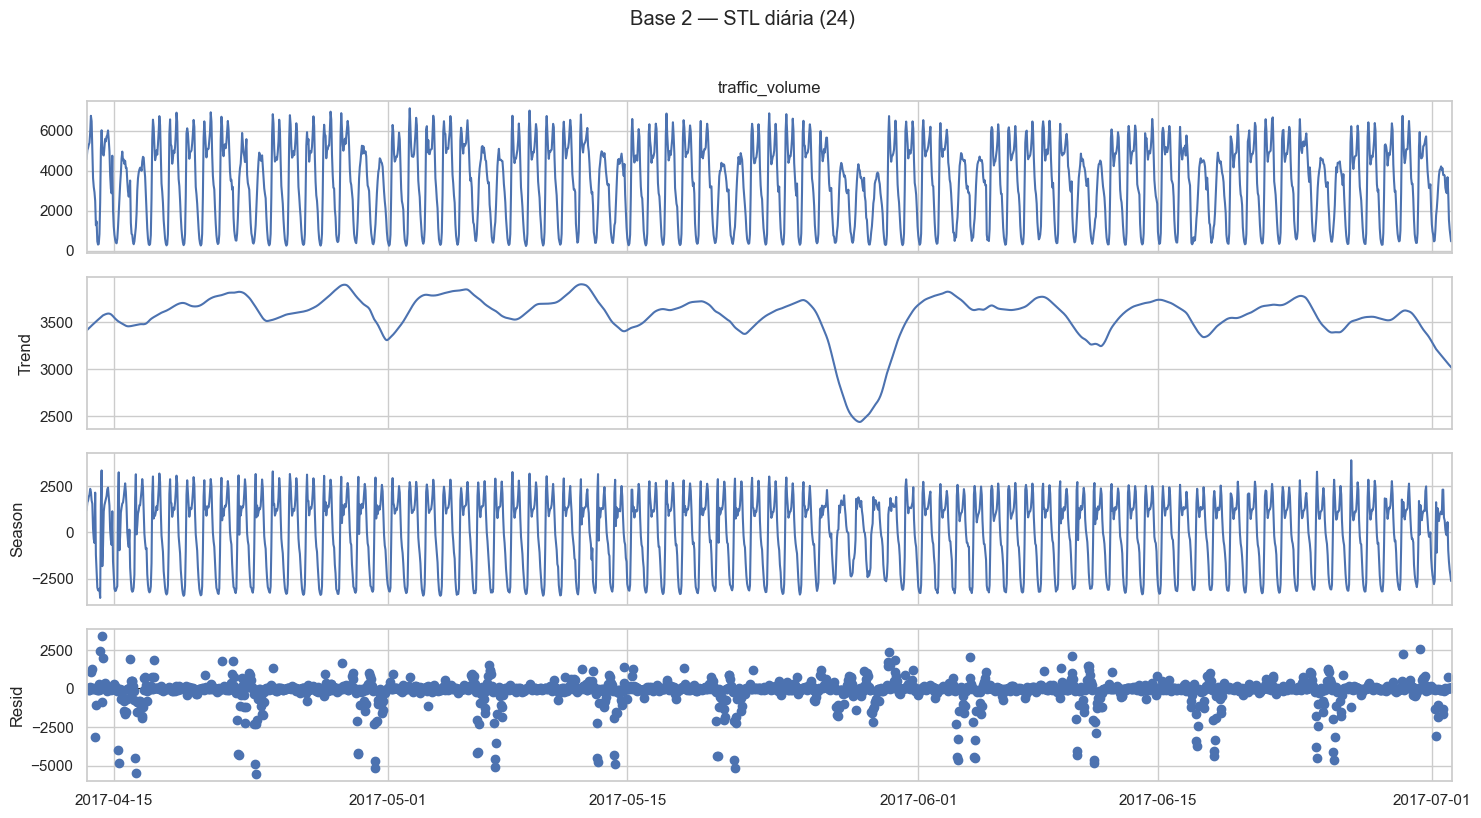

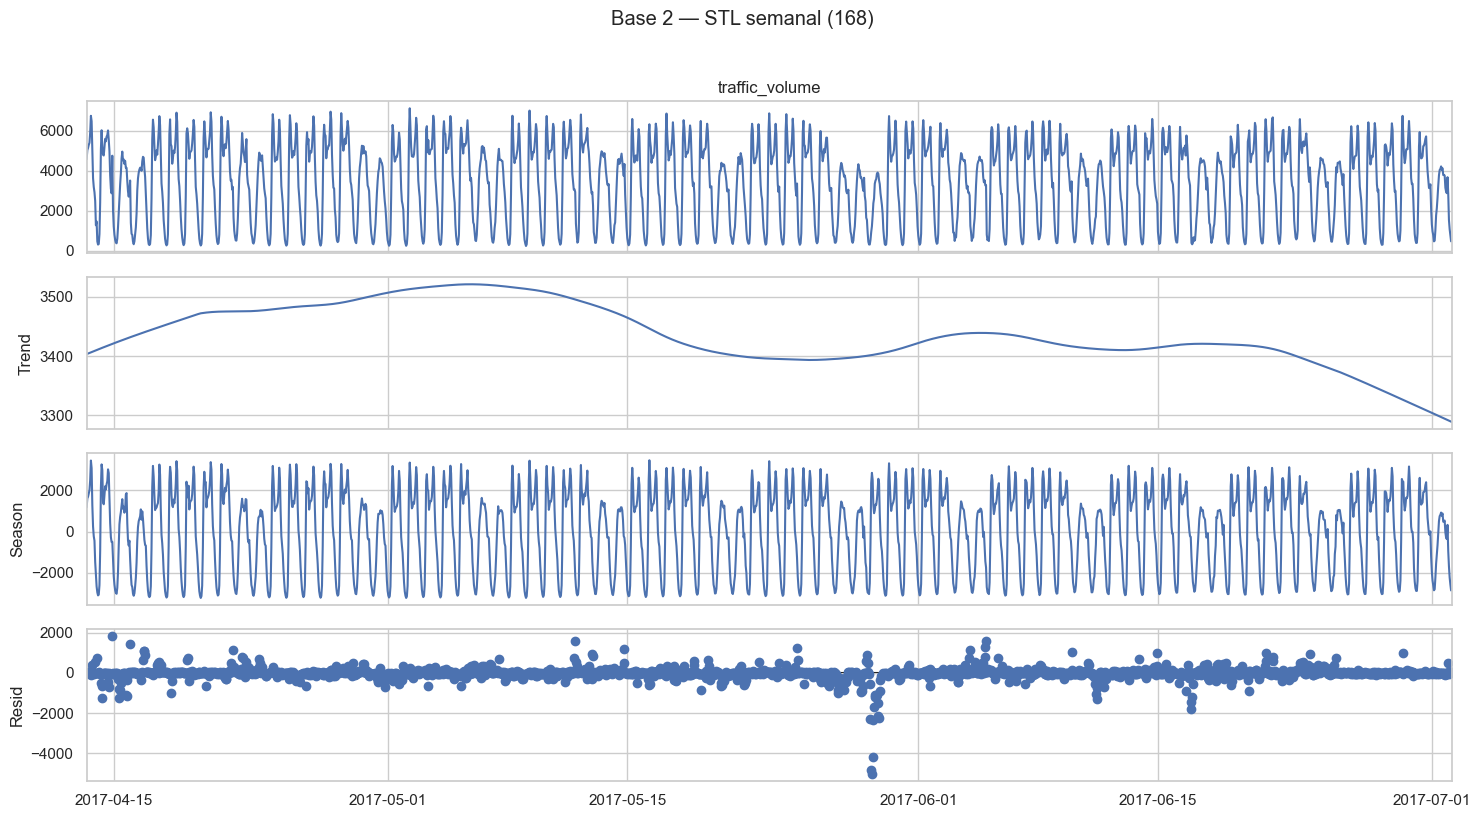

,período,observações/ciclo,força sazonal,força tendência
0,diária (24),24,0.8080,0.1037
1,semanal (168),168,0.9717,0.0386


In [4]:
train_start, train_end = train['date_time'].min(), train['date_time'].max()
serie_treino = df.set_index('date_time').loc[train_start:train_end, 'traffic_volume'].asfreq('h')
observada = serie_treino.notna()
blocks = observada.ne(observada.shift()).cumsum()
sizes = observada.groupby(blocks).agg(['first', 'size'])
valid_blocks = sizes[sizes['first']]
block_id = valid_blocks['size'].idxmax()
maior_trecho = serie_treino[blocks.eq(block_id)]
print('Maior trecho horário contínuo no treino:', len(maior_trecho), 'observações')
if len(maior_trecho) < 2 * 168:
    raise ValueError('Trecho contínuo insuficiente para STL diária e semanal.')

results = {}
for label, period in {'diária (24)': 24, 'semanal (168)': 168}.items():
    result = STL(maior_trecho, period=period, robust=True).fit()
    results[label] = result
    result.plot().set_size_inches(15, 8)
    plt.suptitle(f'Base 2 — STL {label}', y=1.02)
    plt.tight_layout(); plt.show()
display(pd.DataFrame([{'período': k, 'observações/ciclo': 24 if '24' in k else 168, 'força sazonal': seasonal_strength(v), 'força tendência': trend_strength(v)} for k, v in results.items()]).round(4))

## Interpretação

A STL é exploratória e utiliza somente o maior trecho contínuo de treino; não houve interpolação do alvo. Os períodos de 24 e 168 horas são candidatos para validação posterior, não uma decisão final de modelagem.